# Numerical study of $r$ analytical expression

In this notebook a numerical study of the total reflection coefficient (in amplitude is done).

For this purpose a simplified multilayered structure is used made of BK7, gold and water only (we neglect the chromium).

We are interested by the reflection coefficient as function of the plane wave incidence angle (there is several TM plane waves with different incident angle in the beam considered). 

The analytical expression of the reflection coefficient for one plane wave is:

\begin{equation*}
r_{tot}=r_{12}+\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}},
\end{equation*}

where $r_{ij}$ and $t_{ij}$ are respectively the reflection and transmission coefficients corresponding to the interface from the $i$ to the $j$ layer, the index $1$ corresponds to the BK7 layer, $2$ to the gold layer, $3$ to the water layer, $h$ corresponds to the gold layer thickness and $k_{iz}$ is the $z$ component of the incident plane wave in the $i$ layer. Because of the metallic nature of the layer 2 $k_{2z}$ is an imaginary number: $\color{cyan}{k_{2z}=i\kappa_{z}}$. The reflection and transmission coefficients analytical expressions comes from Fresnel equations in the case of TM polarisation:

\begin{align*}
r_{12}&=\dfrac{\dfrac{k_{1z}}{\epsilon_1}-\dfrac{i\kappa_{z}}{\epsilon_2}}{\dfrac{k_{1z}}{\epsilon_1}+\dfrac{i\kappa_{z}}{\epsilon_2}},\\
r_{21}&=\dfrac{\dfrac{i\kappa_{z}}{\epsilon_2}-\dfrac{k_{1z}}{\epsilon_1}}{\dfrac{k_{1z}}{\epsilon_1}+\dfrac{i\kappa_{z}}{\epsilon_2}}=-r_{12},\\
r_{23}&=\dfrac{\dfrac{i\kappa_{z}}{\epsilon_2}-\dfrac{k_{3z}}{\epsilon_3}}{\dfrac{i\kappa_{z}}{\epsilon_2}+\dfrac{k_{3z}}{\epsilon_3}},\\
t_{12}&=\dfrac{2\dfrac{k_{1z}}{\epsilon_1}}{\dfrac{k_{1z}}{\epsilon_1}+\dfrac{i\kappa_{z}}{\epsilon_2}},\\
t_{21}&=\dfrac{2\dfrac{i\kappa_{z}}{\epsilon_2}}{\dfrac{k_{1z}}{\epsilon_1}+\dfrac{i\kappa_{z}}{\epsilon_2}},
\end{align*}

where $\epsilon_i$ is the relative permittivity of the $i$ layer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PyMoosh as PM

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

First we will check if the previous expressions reach to the same results as PM.

(-10.56415864352163+1.2746084502830082j)
(2.29555015808924+0j)
(1.7689000000000001+0j)


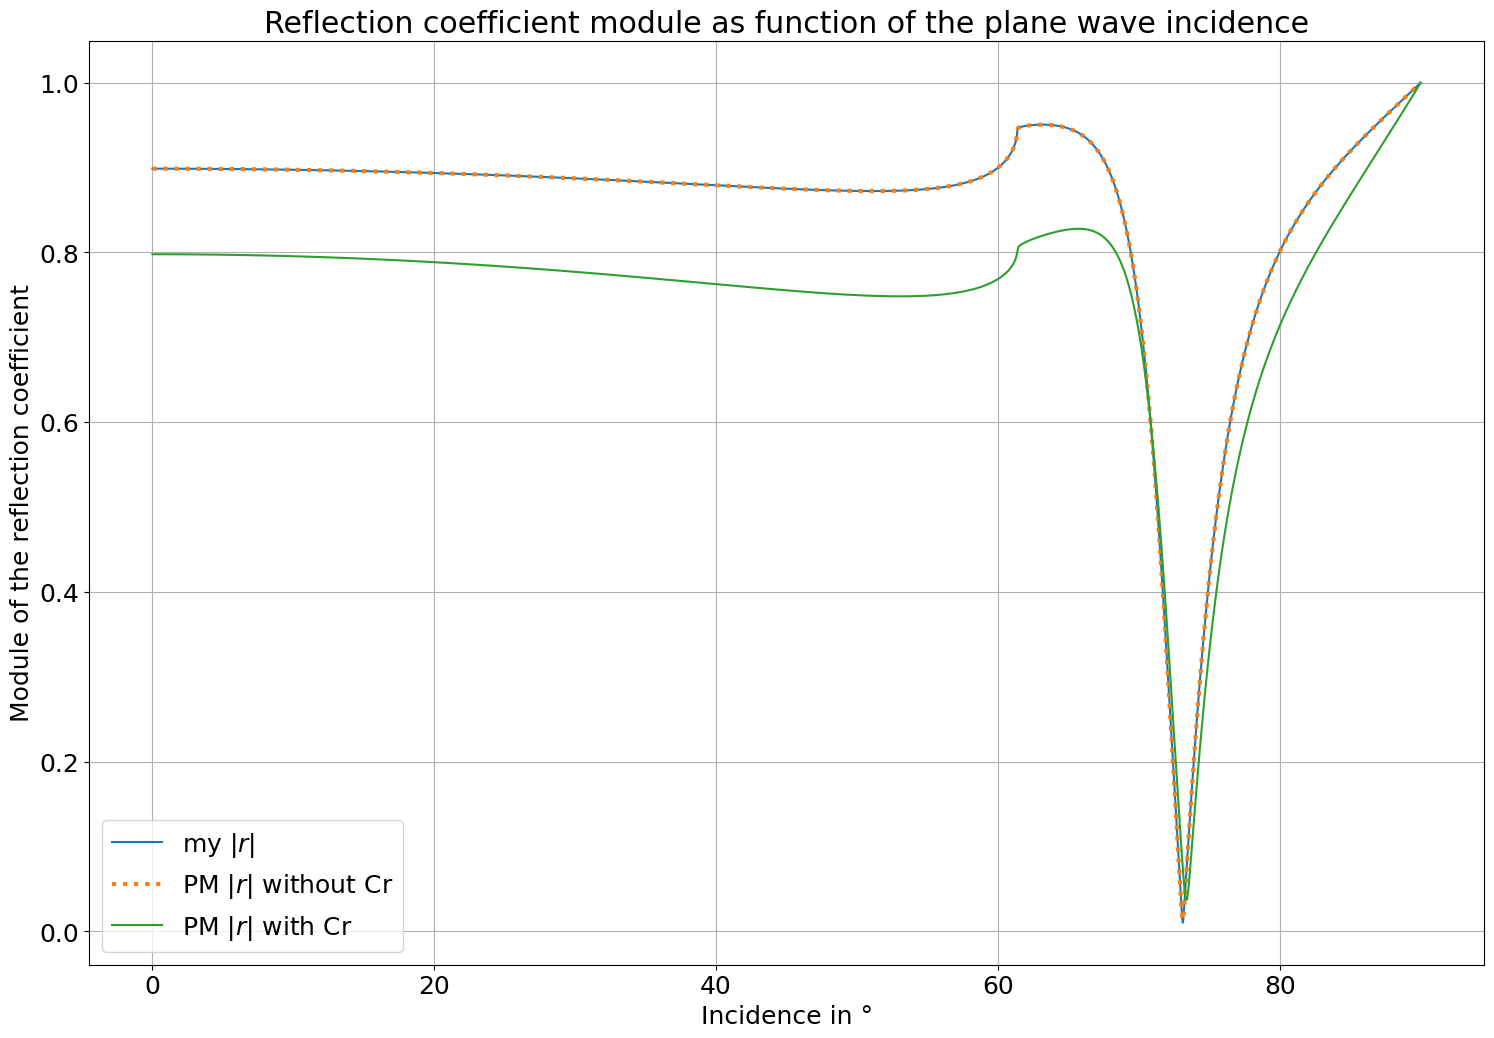

In [2]:
# beam characteristics
wavelength = 632.8
k0 = 2 * np.pi / wavelength
incidences = np.arange(0, 90.01, 0.01)

# get layers permittivities from PM
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
BK7 = PM.Material("BK7")
H2O = PM.Material(1.33**2)

eps_Au = Au.get_permittivity(wavelength)
eps_BK7 = BK7.get_permittivity(wavelength)
eps_H2O = H2O.get_permittivity(wavelength)


print(eps_Au)
print(eps_BK7)
print(eps_H2O)

# gold layer thickness in nm
h_Au = 47

# determination of the wave vector components
kx = np.sqrt(eps_BK7)*k0*np.sin(np.deg2rad(incidences)) # component of the wave vector parallel to the structure surface (noted x but contain both x and y here) for all layers
k1z = np.sqrt(eps_BK7*k0**2-kx**2) # component of the wave vector orthogonal to the structure surface in BK7
kappa2z = np.sqrt(kx**2-eps_Au*k0**2) # component of the wave vector orthogonal to the structure surface in Au is 1j*kappa2z
k3z = np.sqrt(eps_H2O*k0**2-kx**2) # component of the wave vector orthogonal to the structure surface in water

# computation of the reflection and transmission coefficients for each interfaces
r12 = ((k1z/eps_BK7)-(1j*kappa2z/eps_Au))/((k1z/eps_BK7)+(1j*kappa2z/eps_Au))
r21 = -r12
r23 = ((1j*kappa2z/eps_Au)-(k3z/eps_H2O))/((1j*kappa2z/eps_Au)+(k3z/eps_H2O))
t12 = (2*(k1z/eps_BK7))/((k1z/eps_BK7)+(1j*kappa2z/eps_Au))
t21 = (2*(1j*kappa2z/eps_Au))/((k1z/eps_BK7)+(1j*kappa2z/eps_Au))

# determination of the total reflection coefficient
rtot = r12 + (t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))


# determination with PM for the complete structure (with Cr)
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)
angle, r, t, R, T = PM.angular(structure, wavelength,1, 0, 90,1000)

# determination with PM for the same structure
stack_bis = [0, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness_bis = [4000, h_Au, 1000]  # thickness of each layer
structure_bis = PM.Structure(mat, stack_bis, thickness_bis, verbose=False)
angle_bis, r_bis, t_bis, R_bis, T_bis = PM.angular(structure_bis, wavelength,1, 0, 90,1000)

# comparison of the reflection coefficient determinations 
plt.figure(figsize=(18,12))
plt.plot(incidences,np.abs(rtot), label=r"my $|r|$")
plt.plot(angle_bis,np.abs(r_bis), ":", linewidth=3,label=r"PM $|r|$ without Cr")
plt.plot(angle,np.abs(r), label=r"PM $|r|$ with Cr")
plt.title("Reflection coefficient module as function of the plane wave incidence")
plt.xlabel(f"Incidence in °")
plt.ylabel("Module of the reflection coefficient")
plt.legend()
plt.grid();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/my_r_vs_PM.{file_ext}", bbox_inches="tight")

The expressions lead to the same results as PM !

Now we will scrutinize deeper the reflection coefficient.

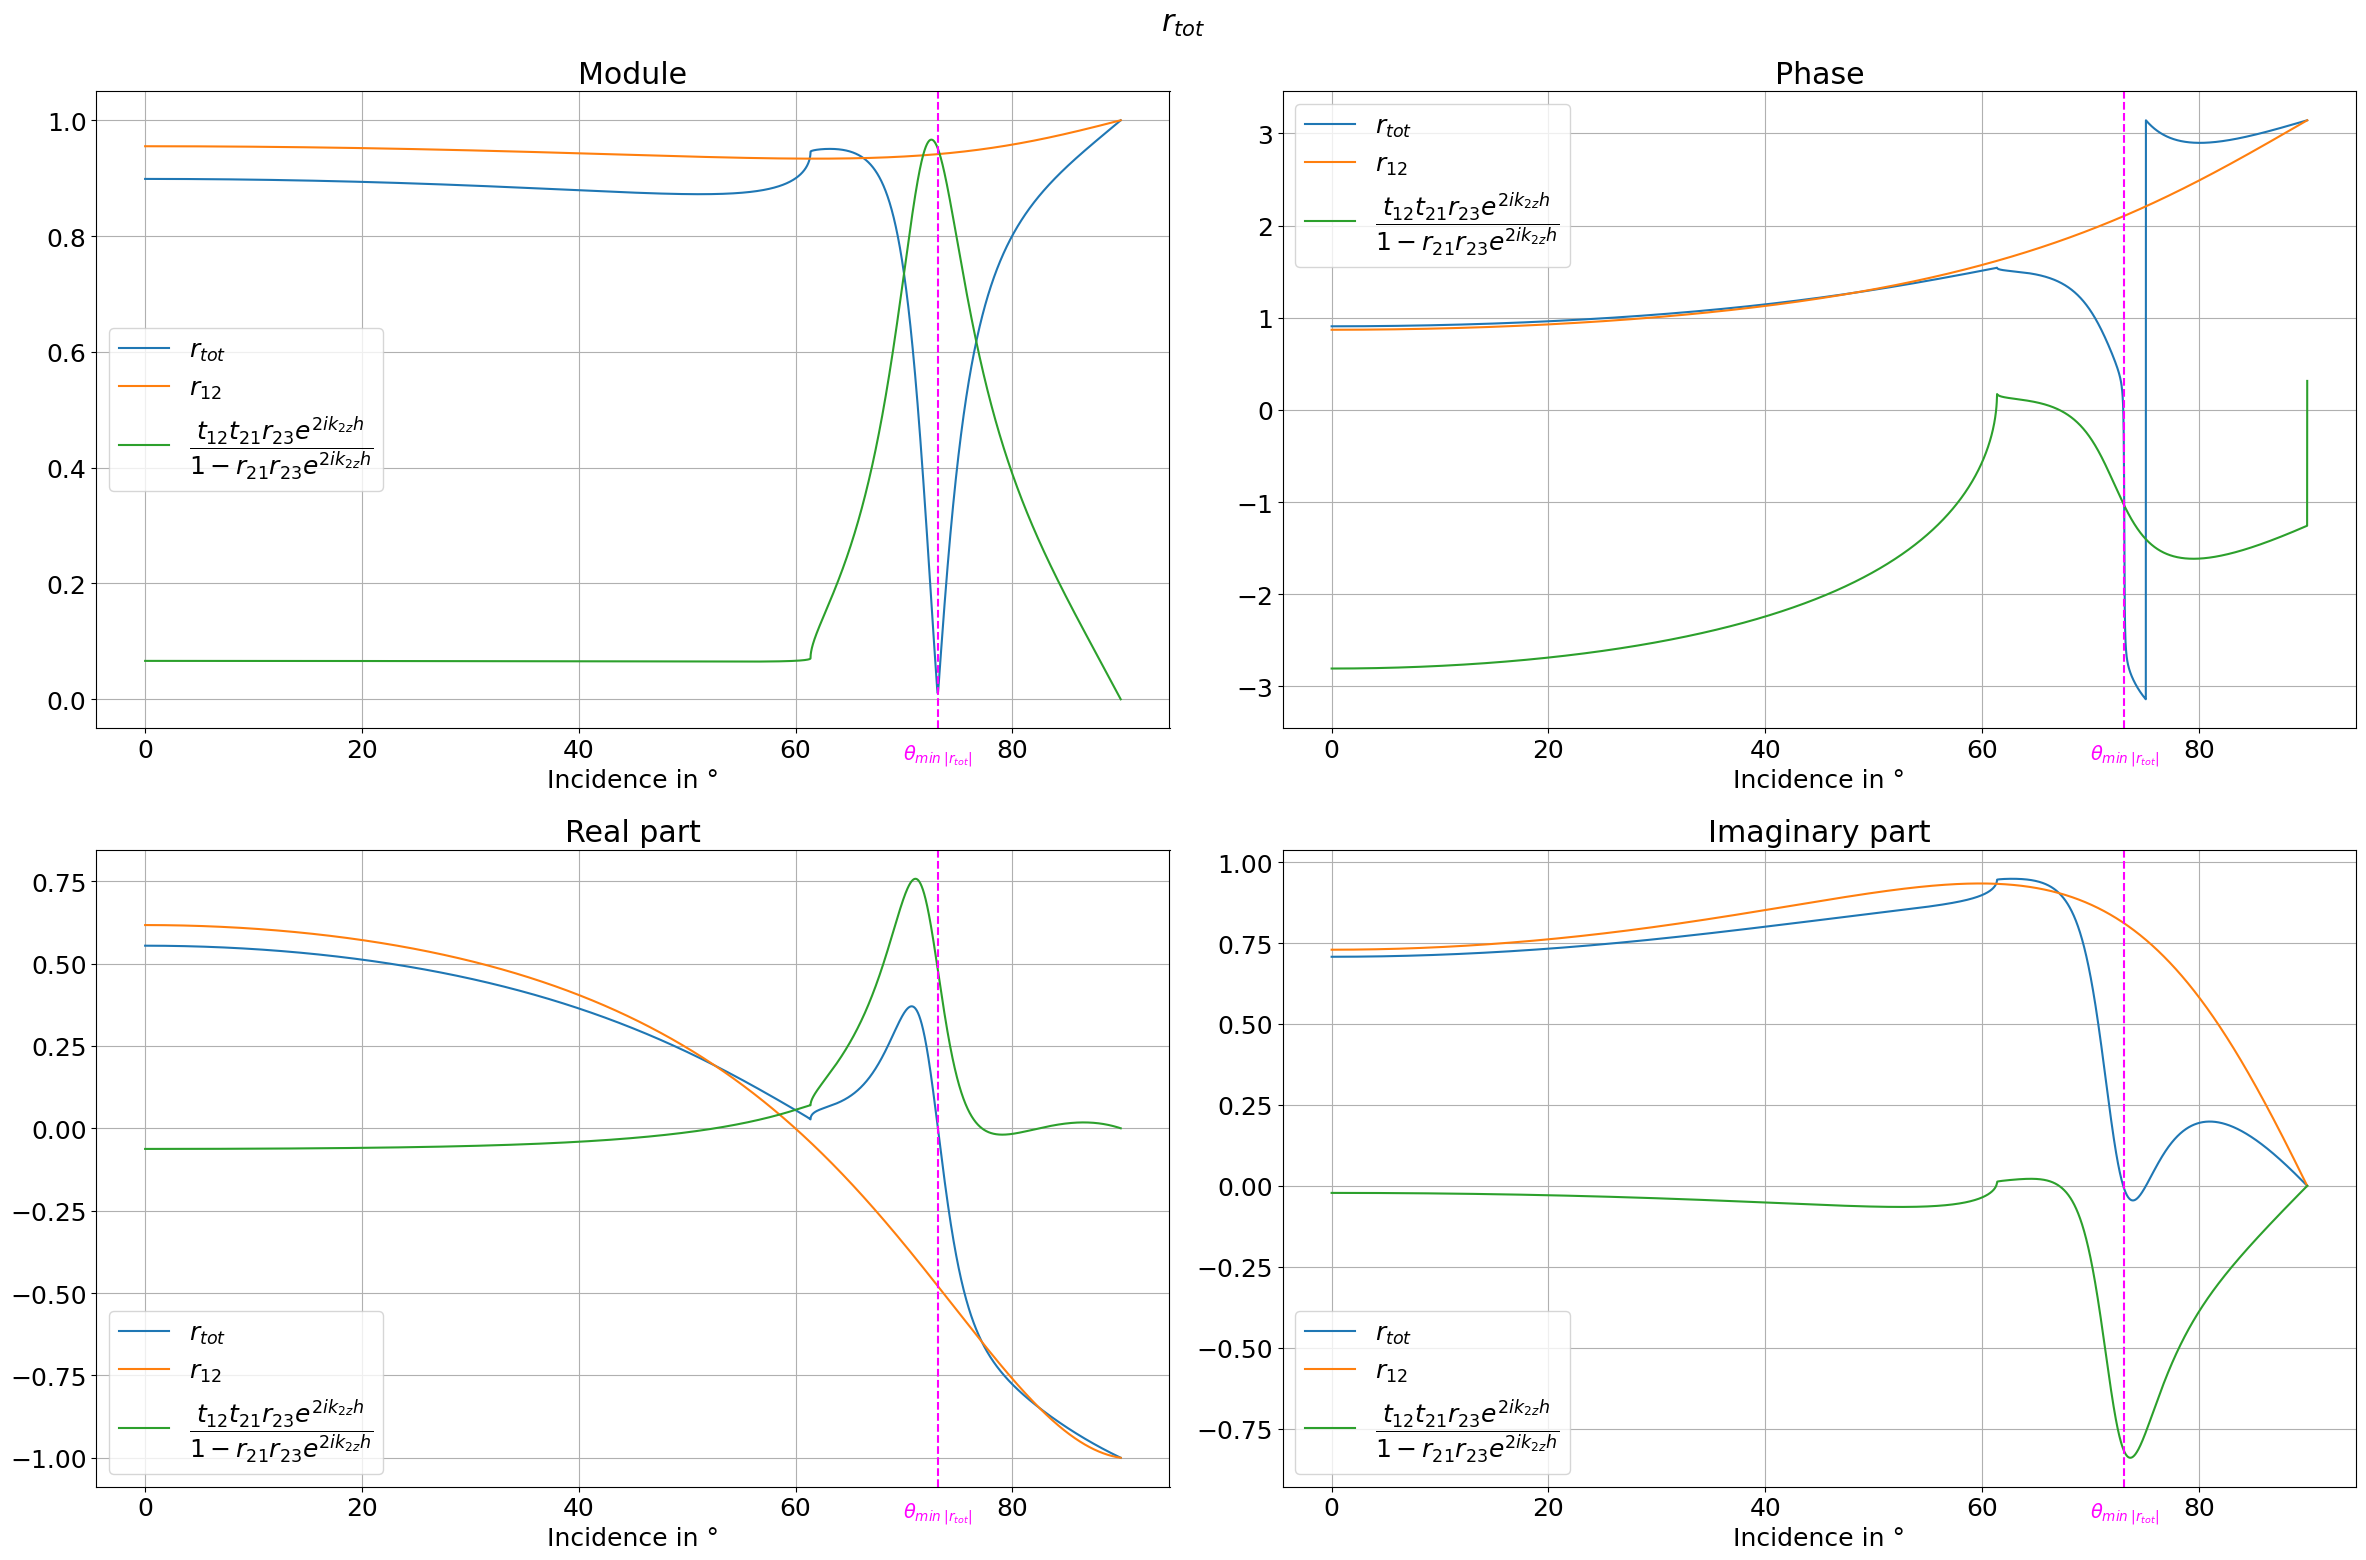

In [4]:
min_rtot_loc=incidences[np.argmin(np.abs(rtot))]
plt.figure(figsize=(24, 16))
plt.suptitle(r"$r_{tot}$")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs(rtot), label=r"$r_{tot}$")
ax1.plot(incidences, np.abs(r12), label=r"$r_{12}$")
ax1.plot(incidences, np.abs((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle(rtot), label=r"$r_{tot}$")
ax2.plot(incidences, np.angle(r12), label=r"$r_{12}$")
ax2.plot(incidences, np.angle((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real(rtot), label=r"$r_{tot}$")
ax3.plot(incidences, np.real(r12), label=r"$r_{12}$")
ax3.plot(incidences, np.real((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag(rtot), label=r"$r_{tot}$")
ax4.plot(incidences, np.imag(r12), label=r"$r_{12}$")
ax4.plot(incidences, np.imag((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot.{file_ext}", bbox_inches="tight")

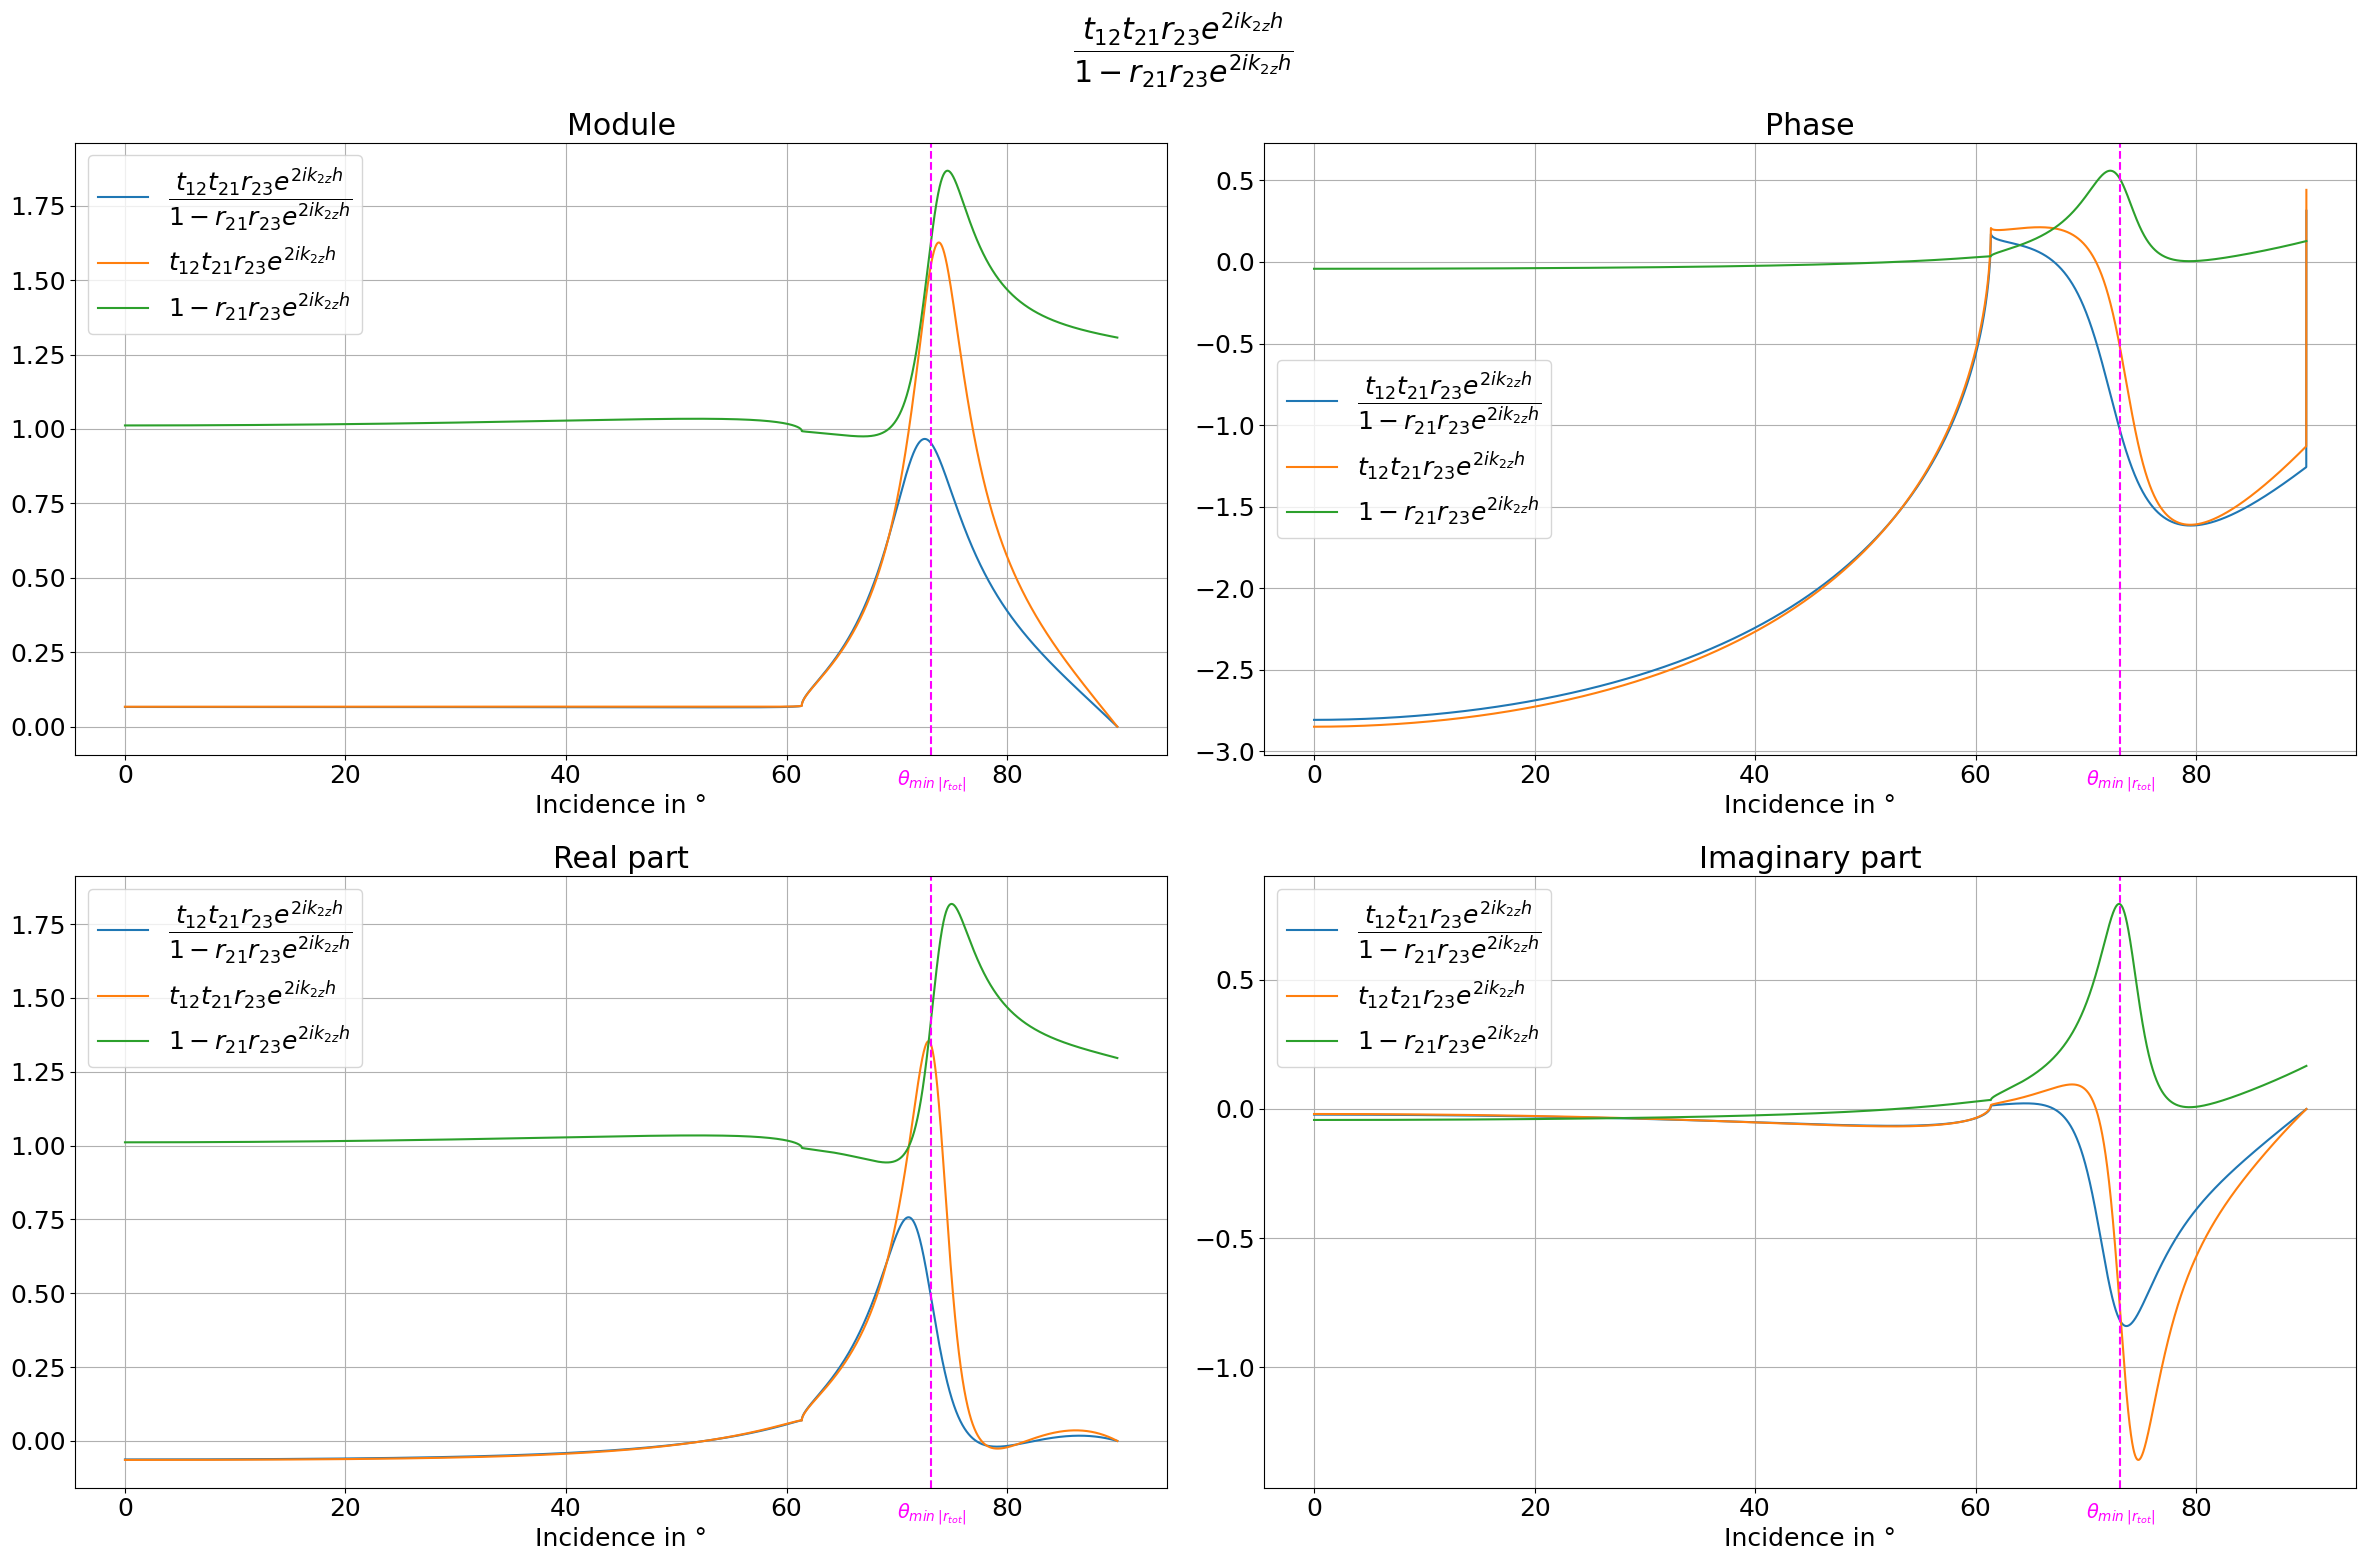

In [5]:
plt.figure(figsize=(24, 16))
plt.suptitle(r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax1.plot(incidences, np.abs((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax1.plot(incidences, np.abs((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax2.plot(incidences, np.angle((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax2.plot(incidences, np.angle((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax3.plot(incidences, np.real((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax3.plot(incidences, np.real((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag((t12*t21*r23*np.exp(-2*kappa2z*h_Au)/(1-r21*r23*np.exp(-2*kappa2z*h_Au)))), label=r"$\dfrac{t_{12}t_{21}r_{23}e^{2ik_{2z}h}}{1-r_{21}r_{23}e^{2ik_{2z}h}}$")
ax4.plot(incidences, np.imag((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax4.plot(incidences, np.imag((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot_right_term.{file_ext}", bbox_inches="tight")

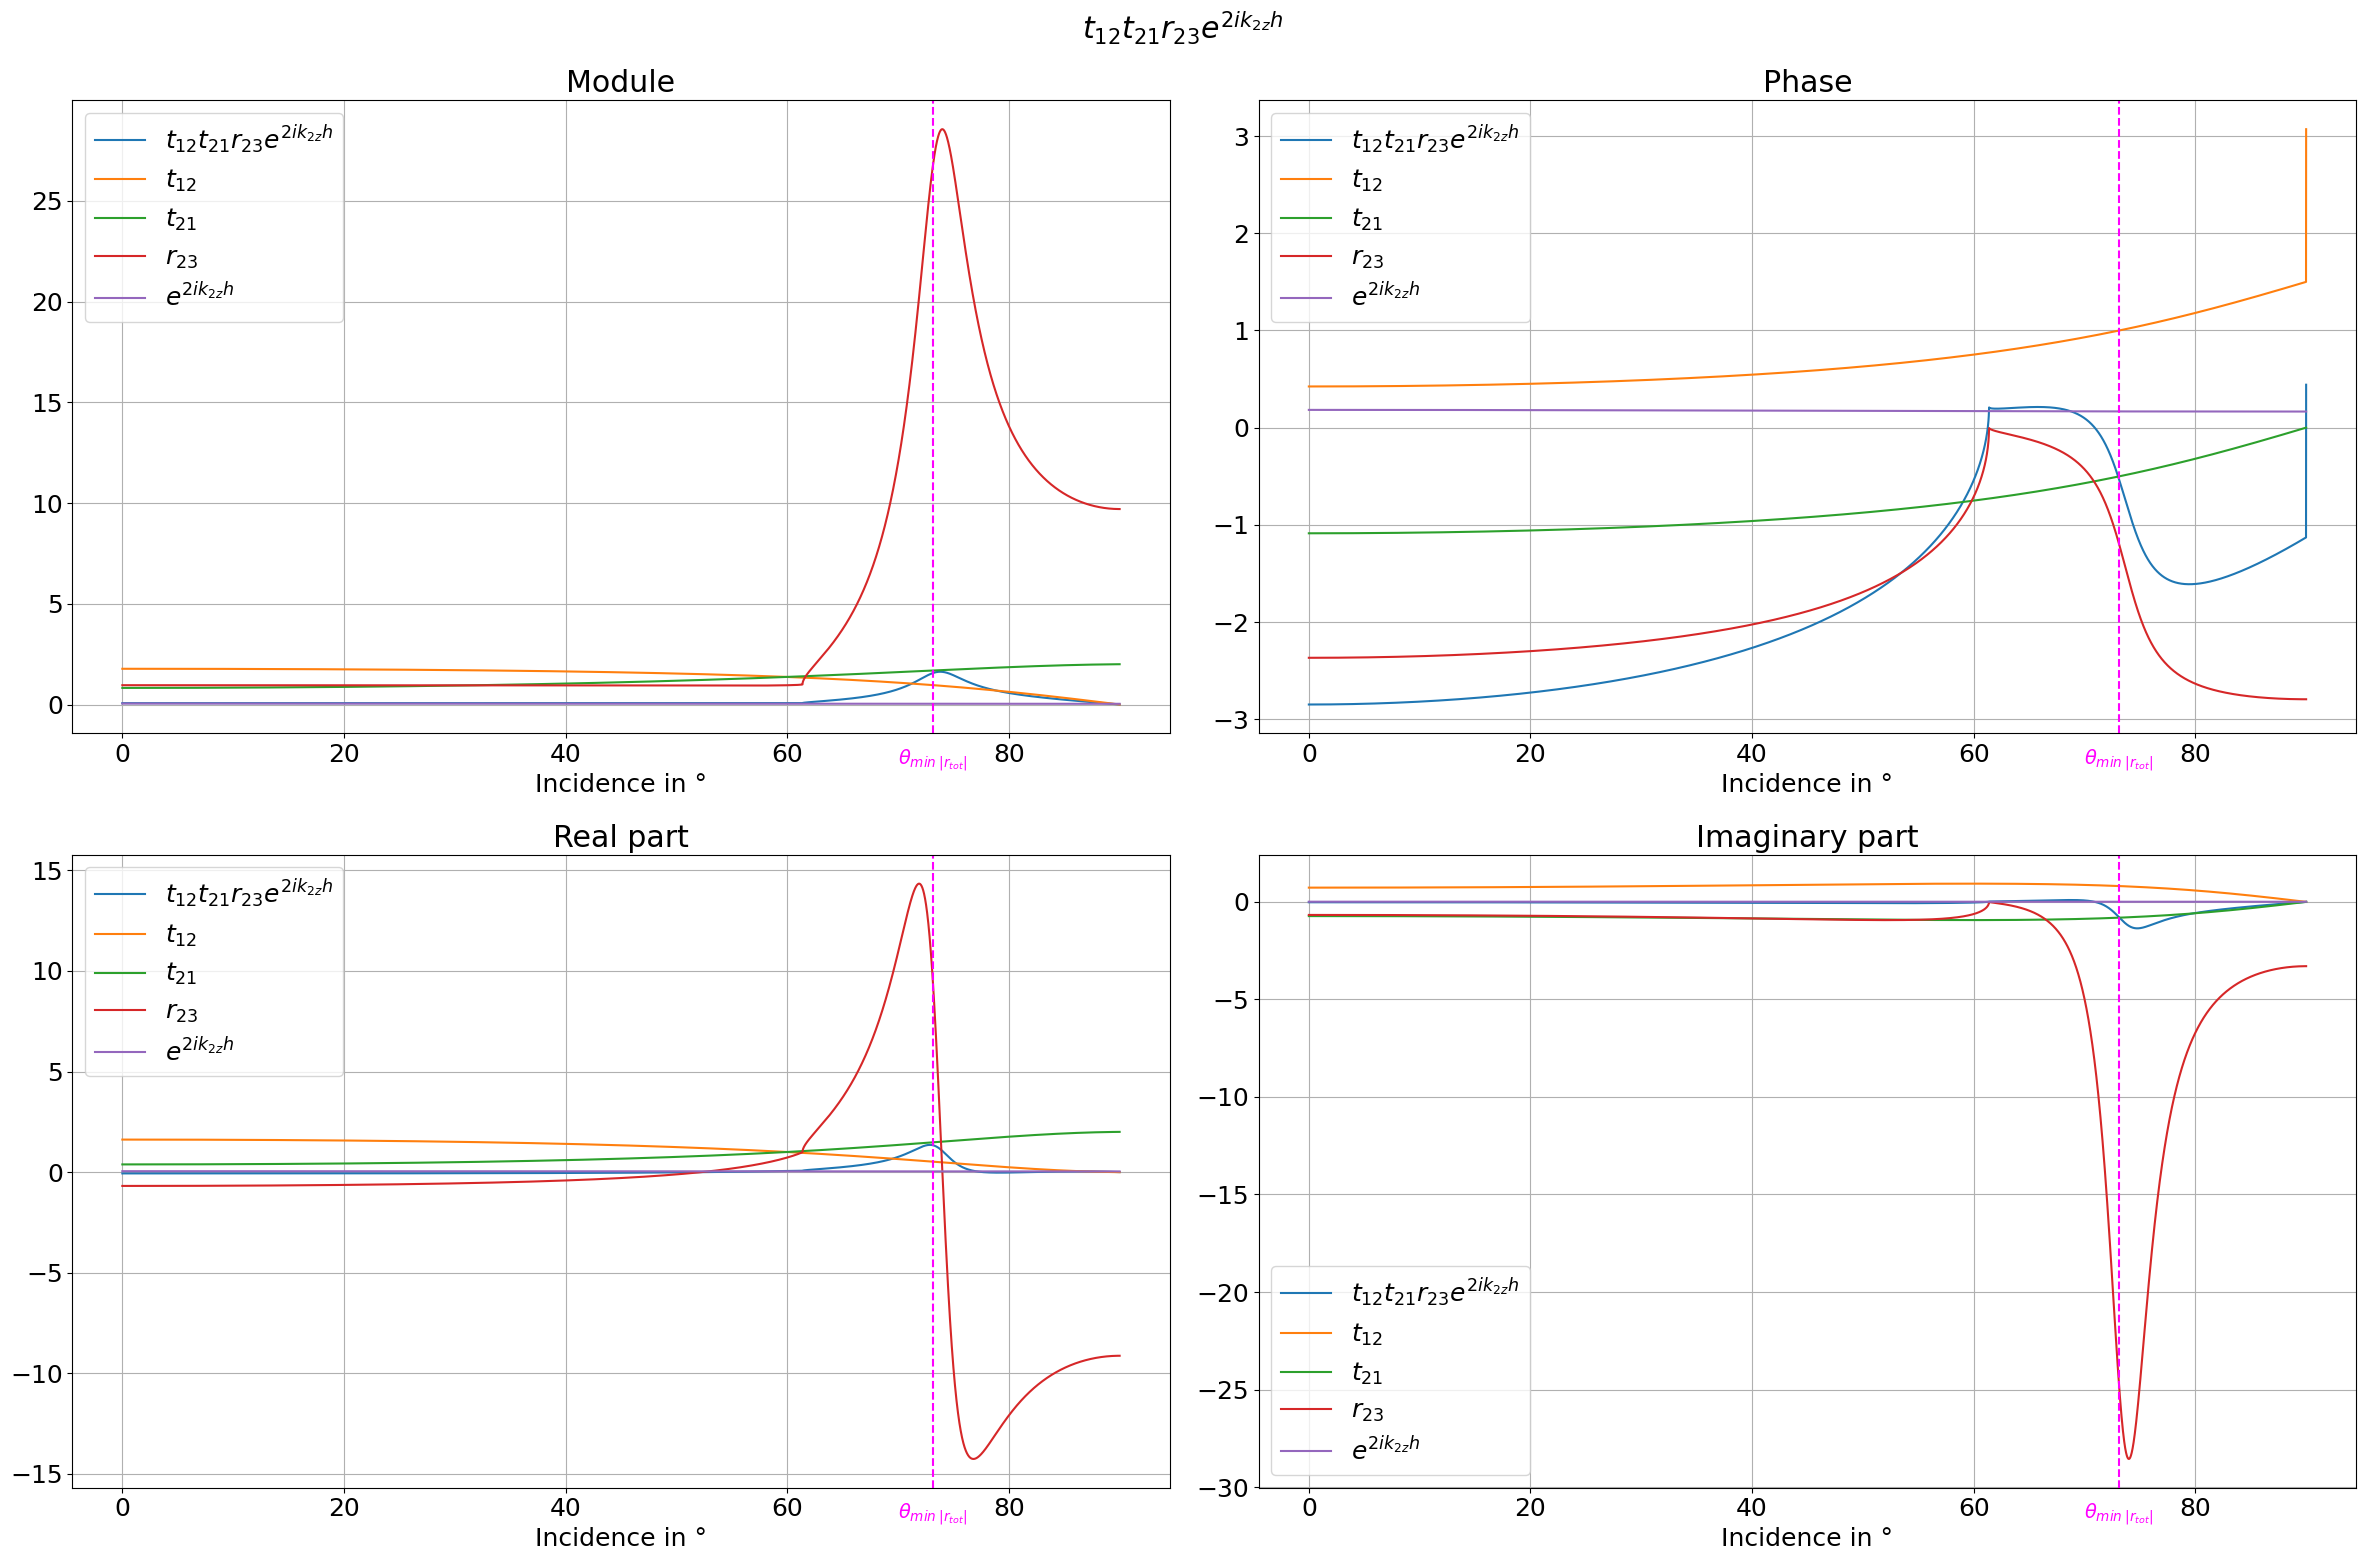

In [6]:
plt.figure(figsize=(24, 16))
plt.suptitle(r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax1.plot(incidences, np.abs(t12), label=r"$t_{12}$")
ax1.plot(incidences, np.abs(t21), label=r"$t_{21}$")
ax1.plot(incidences, np.abs(r23), label=r"$r_{23}$")
ax1.plot(incidences, np.abs(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax2.plot(incidences, np.angle(t12), label=r"$t_{12}$")
ax2.plot(incidences, np.angle(t21), label=r"$t_{21}$")
ax2.plot(incidences, np.angle(r23), label=r"$r_{23}$")
ax2.plot(incidences, np.angle(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax3.plot(incidences, np.real(t12), label=r"$t_{12}$")
ax3.plot(incidences, np.real(t21), label=r"$t_{21}$")
ax3.plot(incidences, np.real(r23), label=r"$r_{23}$")
ax3.plot(incidences, np.real(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag((t12*t21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$t_{12}t_{21}r_{23}e^{2ik_{2z}h}$")
ax4.plot(incidences, np.imag(t12), label=r"$t_{12}$")
ax4.plot(incidences, np.imag(t21), label=r"$t_{21}$")
ax4.plot(incidences, np.imag(r23), label=r"$r_{23}$")
ax4.plot(incidences, np.imag(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot_right_term_num.{file_ext}", bbox_inches="tight")

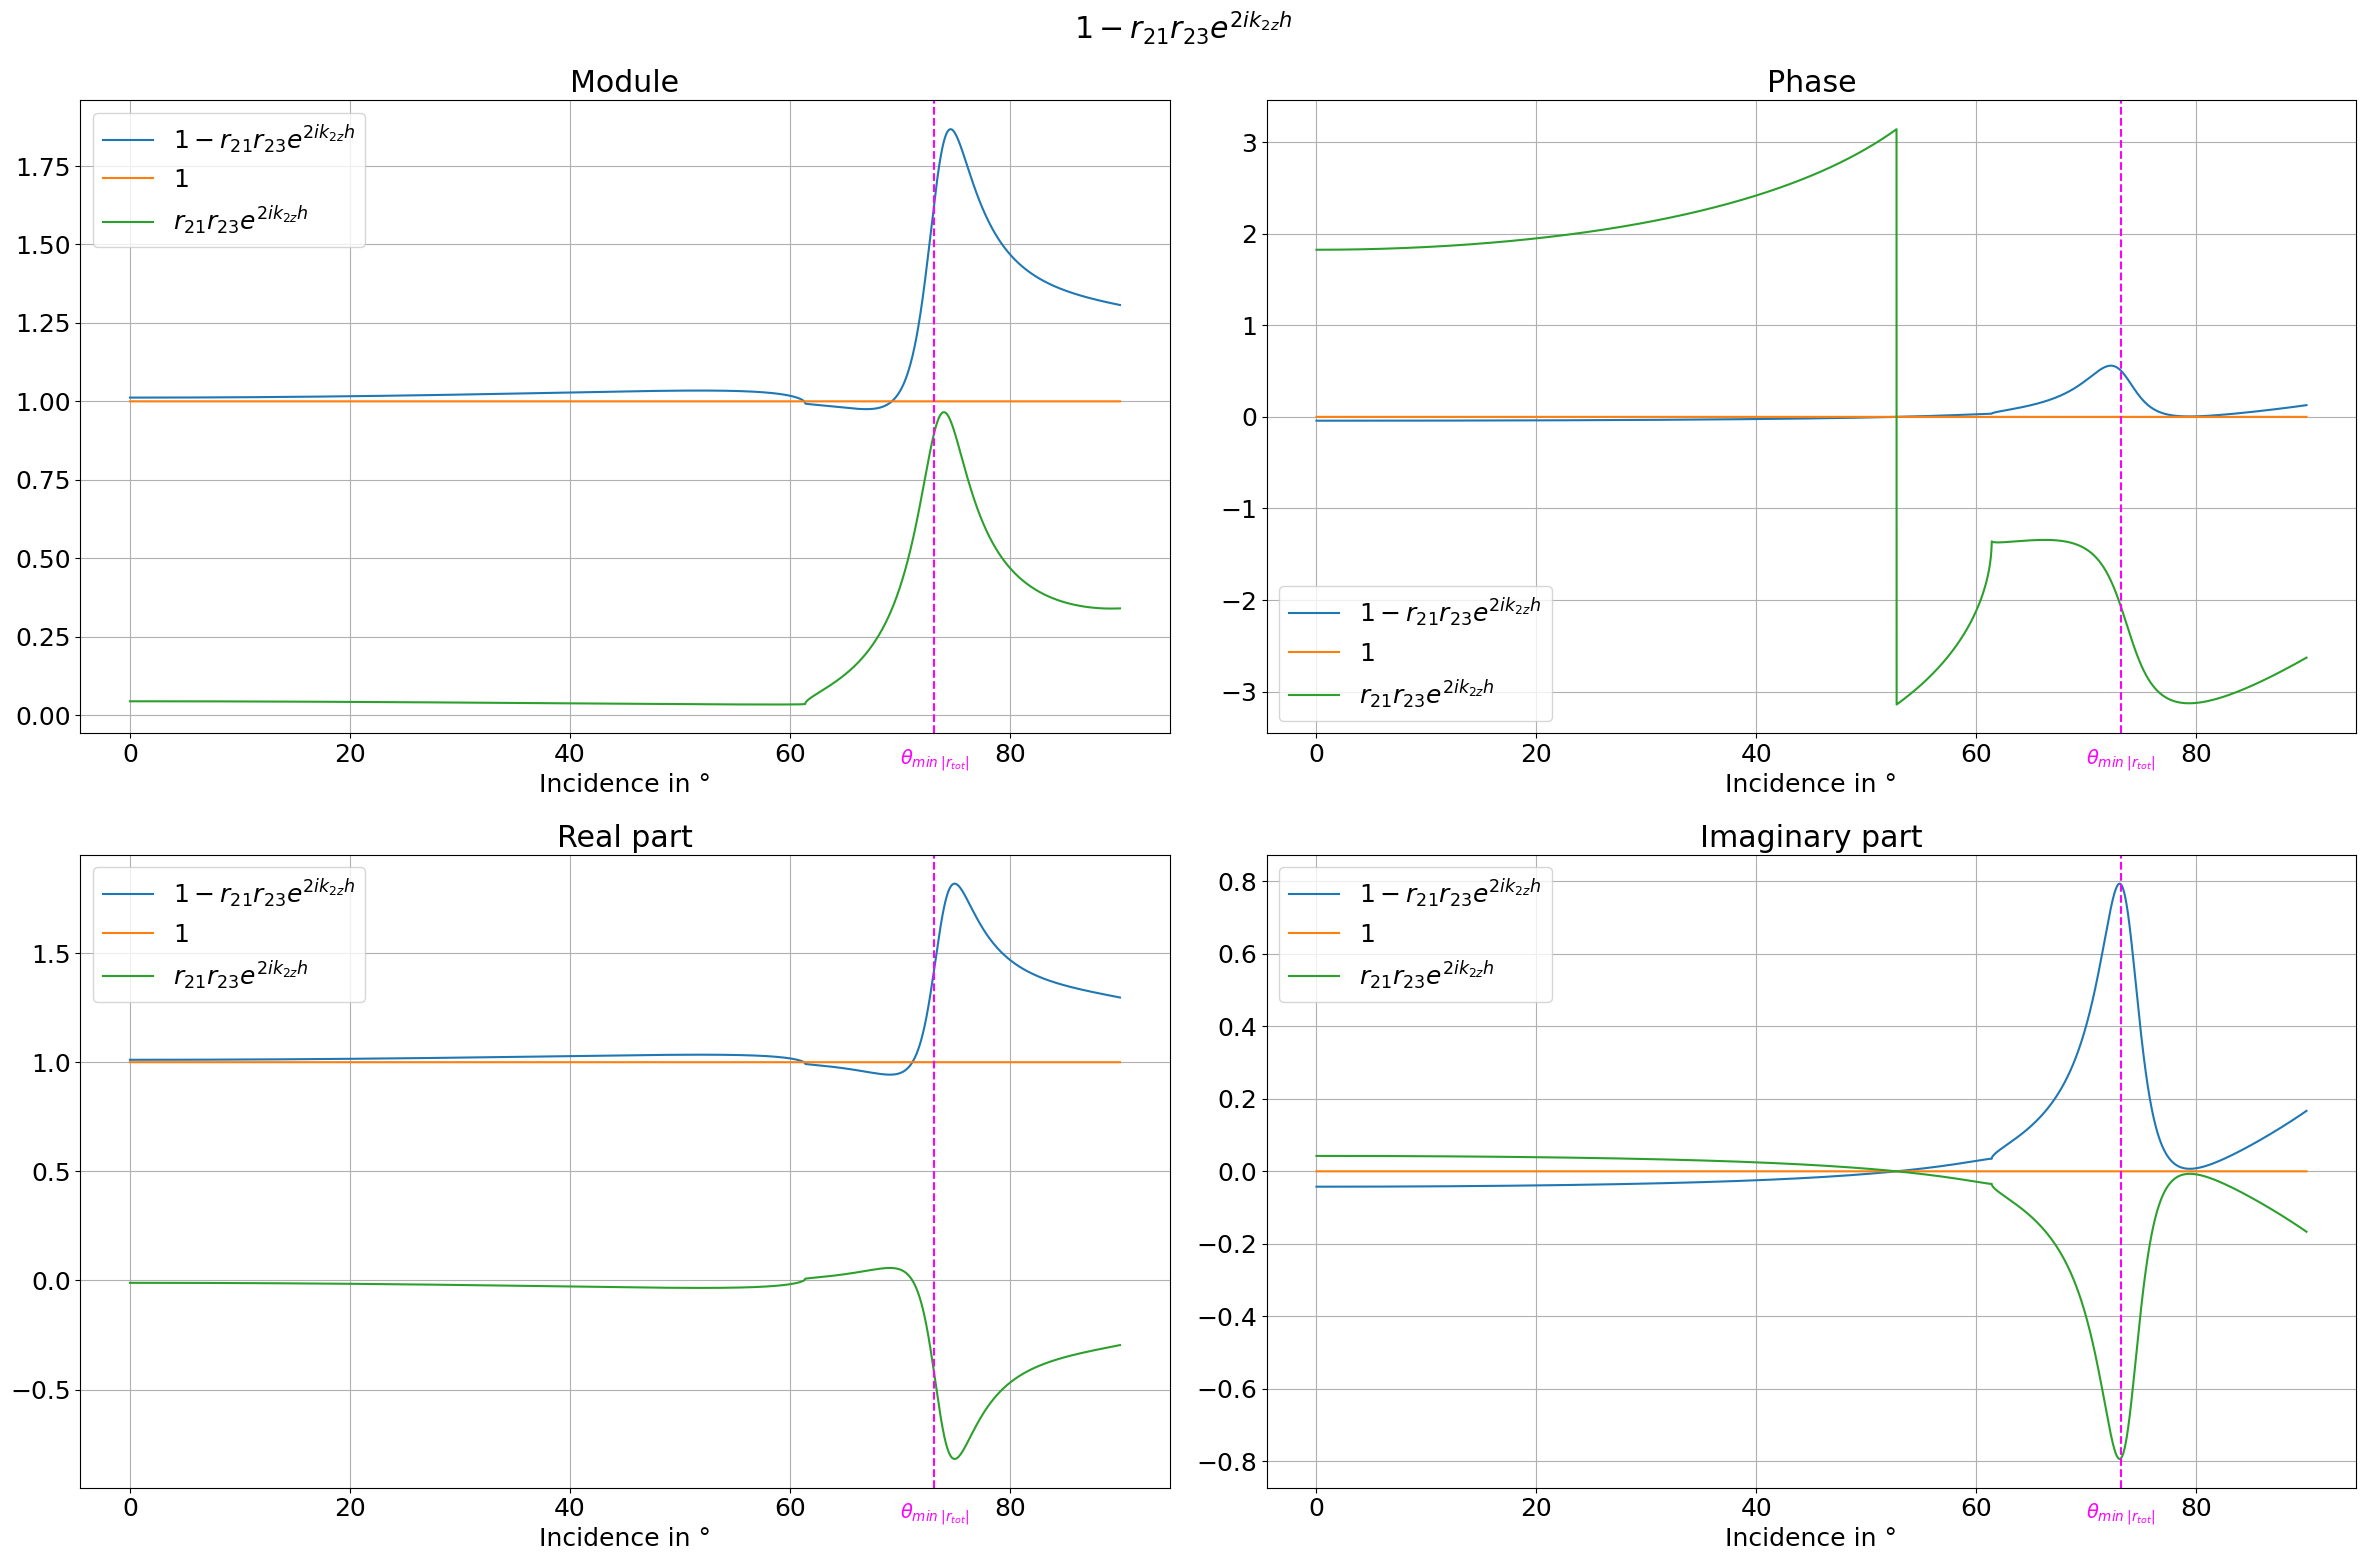

In [7]:
plt.figure(figsize=(24, 16))
plt.suptitle(r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax1.plot(incidences, np.abs(0*incidences+1), label=r"$1$")
ax1.plot(incidences, np.abs(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax2.plot(incidences, np.angle(0*incidences+1), label=r"$1$")
ax2.plot(incidences, np.angle(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax3.plot(incidences, np.real(0*incidences+1), label=r"$1$")
ax3.plot(incidences, np.real(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag((1-r21*r23*np.exp(-2*kappa2z*h_Au))), label=r"$1-r_{21}r_{23}e^{2ik_{2z}h}$")
ax4.plot(incidences, np.imag(0*incidences+1), label=r"$1$")
ax4.plot(incidences, np.imag(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot_right_term_denom.{file_ext}", bbox_inches="tight")

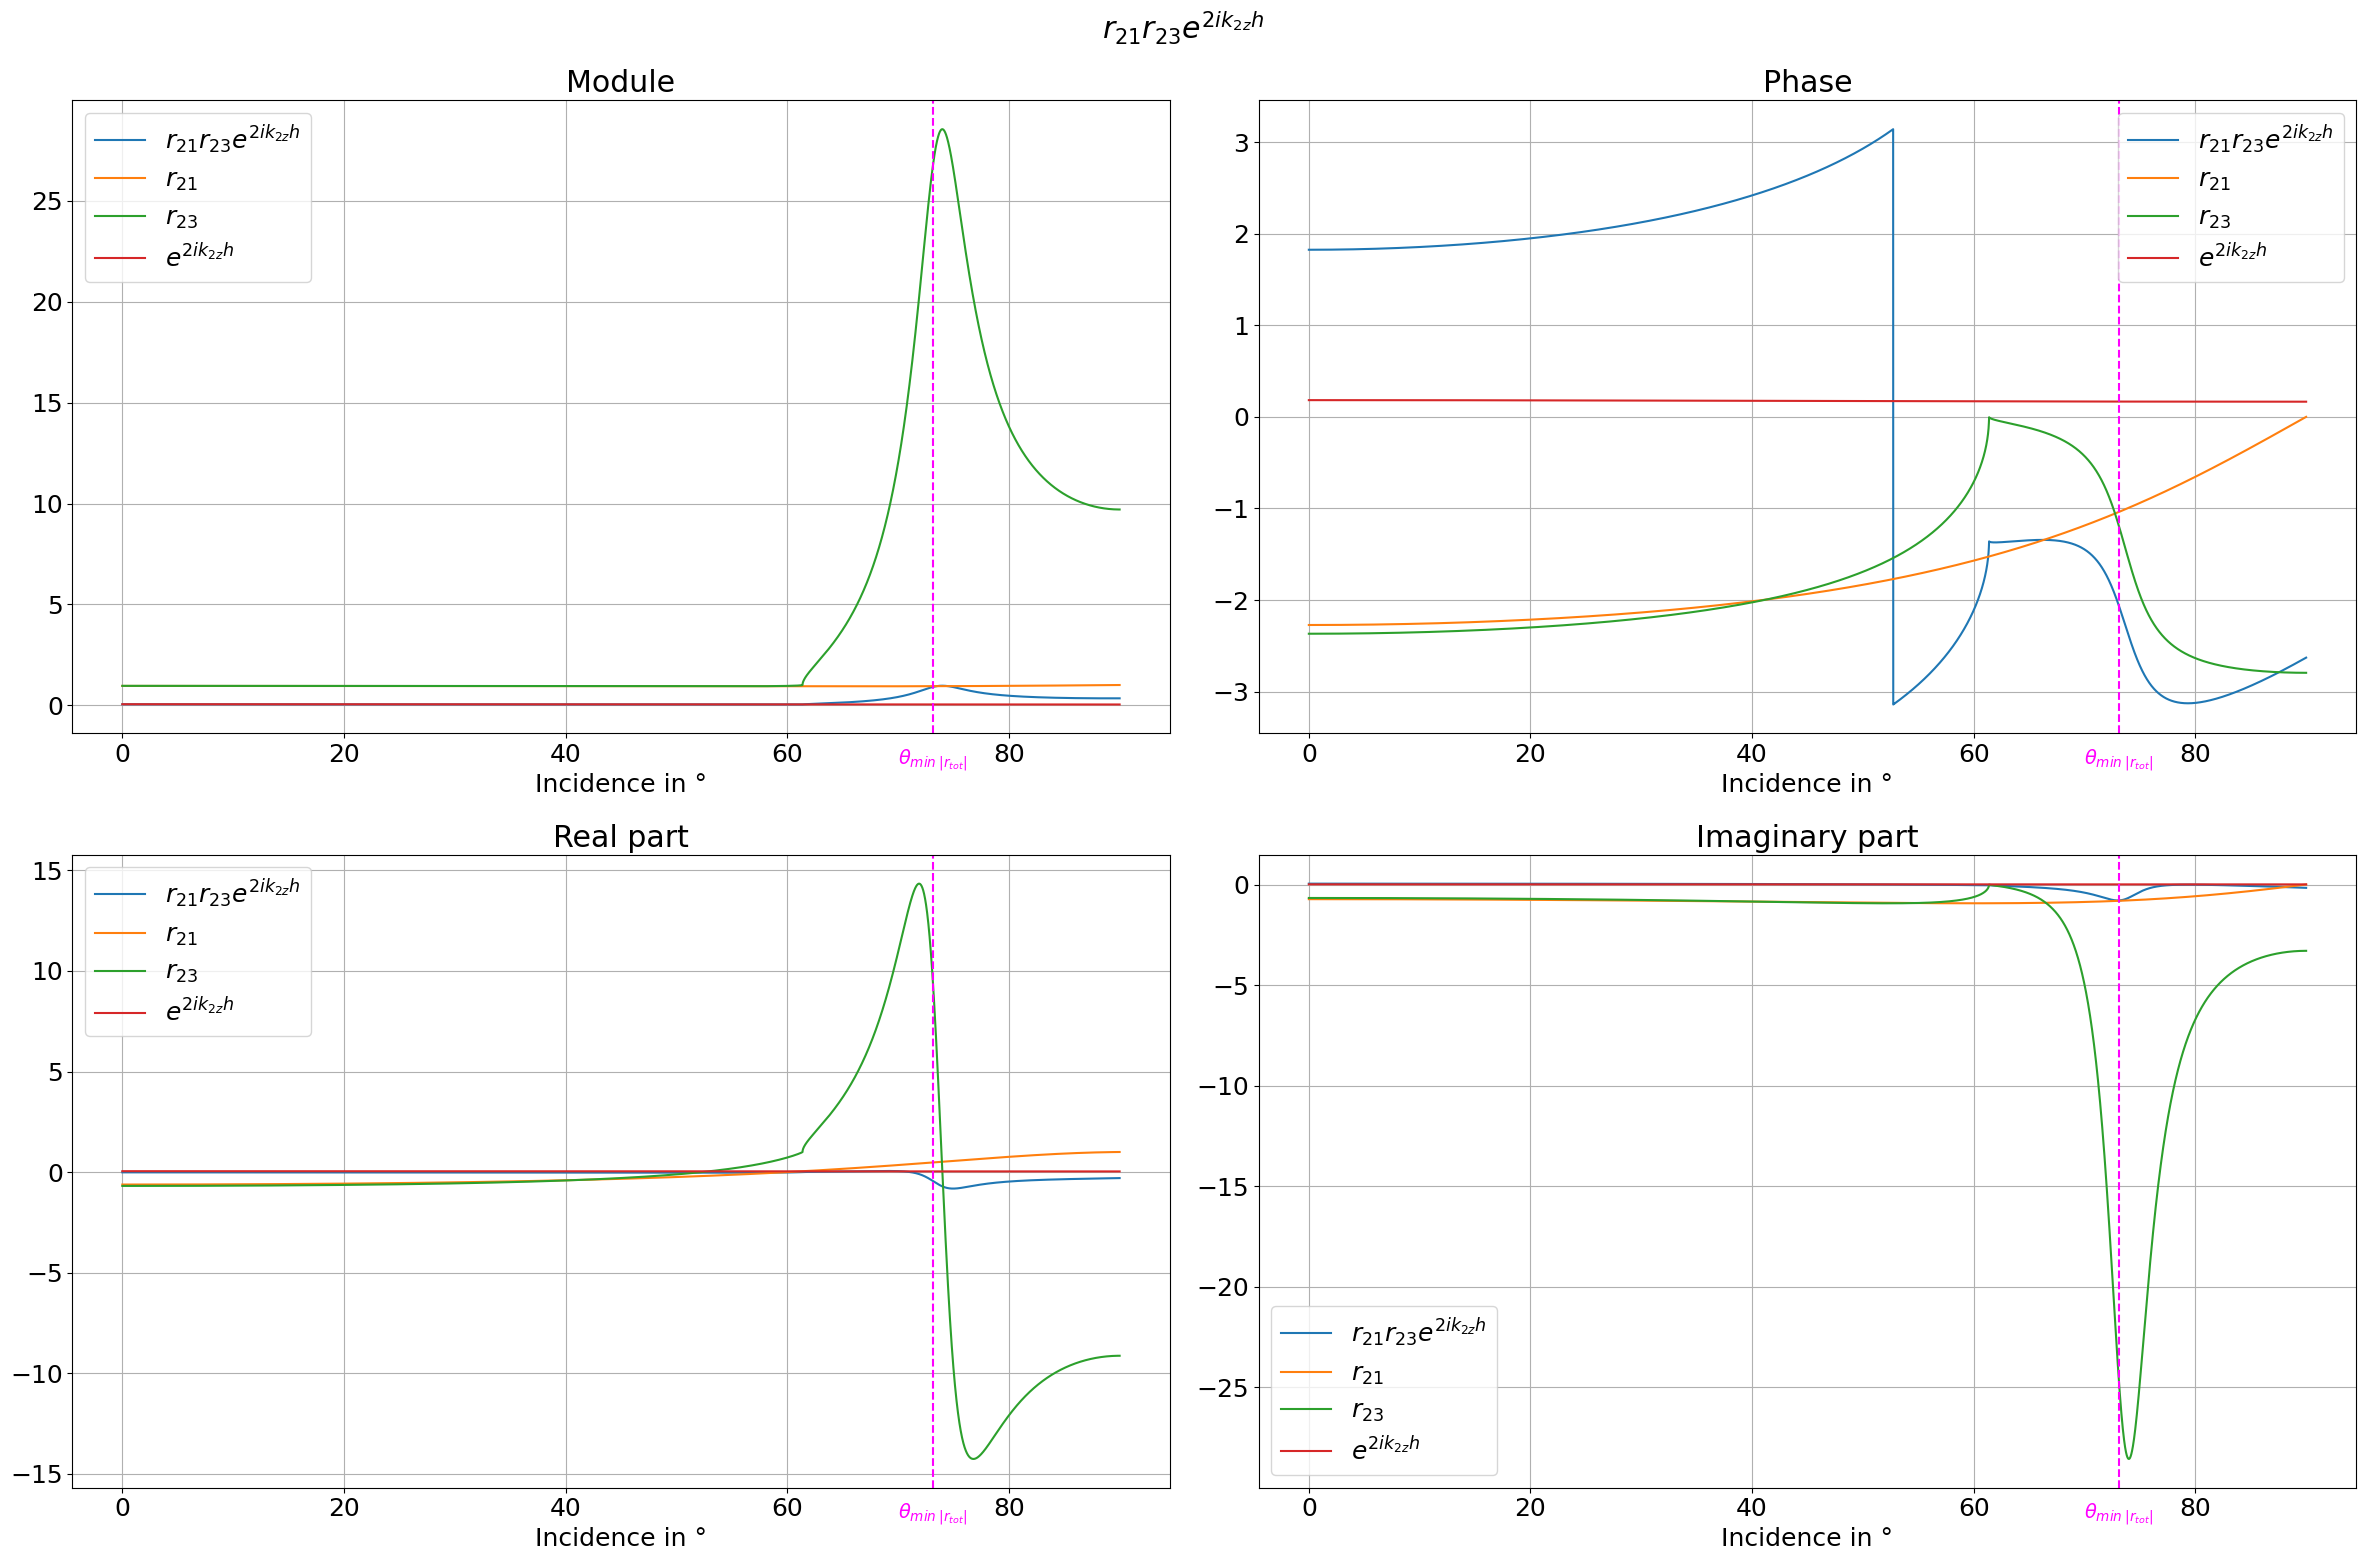

In [8]:
plt.figure(figsize=(24, 16))
plt.suptitle(r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax1.plot(incidences, np.abs(r21), label=r"$r_{21}$")
ax1.plot(incidences, np.abs(r23), label=r"$r_{23}$")
ax1.plot(incidences, np.abs(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax2.plot(incidences, np.angle(r21), label=r"$r_{21}$")
ax2.plot(incidences, np.angle(r23), label=r"$r_{23}$")
ax2.plot(incidences, np.angle(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax3.plot(incidences, np.real(r21), label=r"$r_{21}$")
ax3.plot(incidences, np.real(r23), label=r"$r_{23}$")
ax3.plot(incidences, np.real(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag(r21*r23*np.exp(-2*kappa2z*h_Au)), label=r"$r_{21}r_{23}e^{2ik_{2z}h}$")
ax4.plot(incidences, np.imag(r21), label=r"$r_{21}$")
ax4.plot(incidences, np.imag(r23), label=r"$r_{23}$")
ax4.plot(incidences, np.imag(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot_right_term_denom_right_term.{file_ext}", bbox_inches="tight")

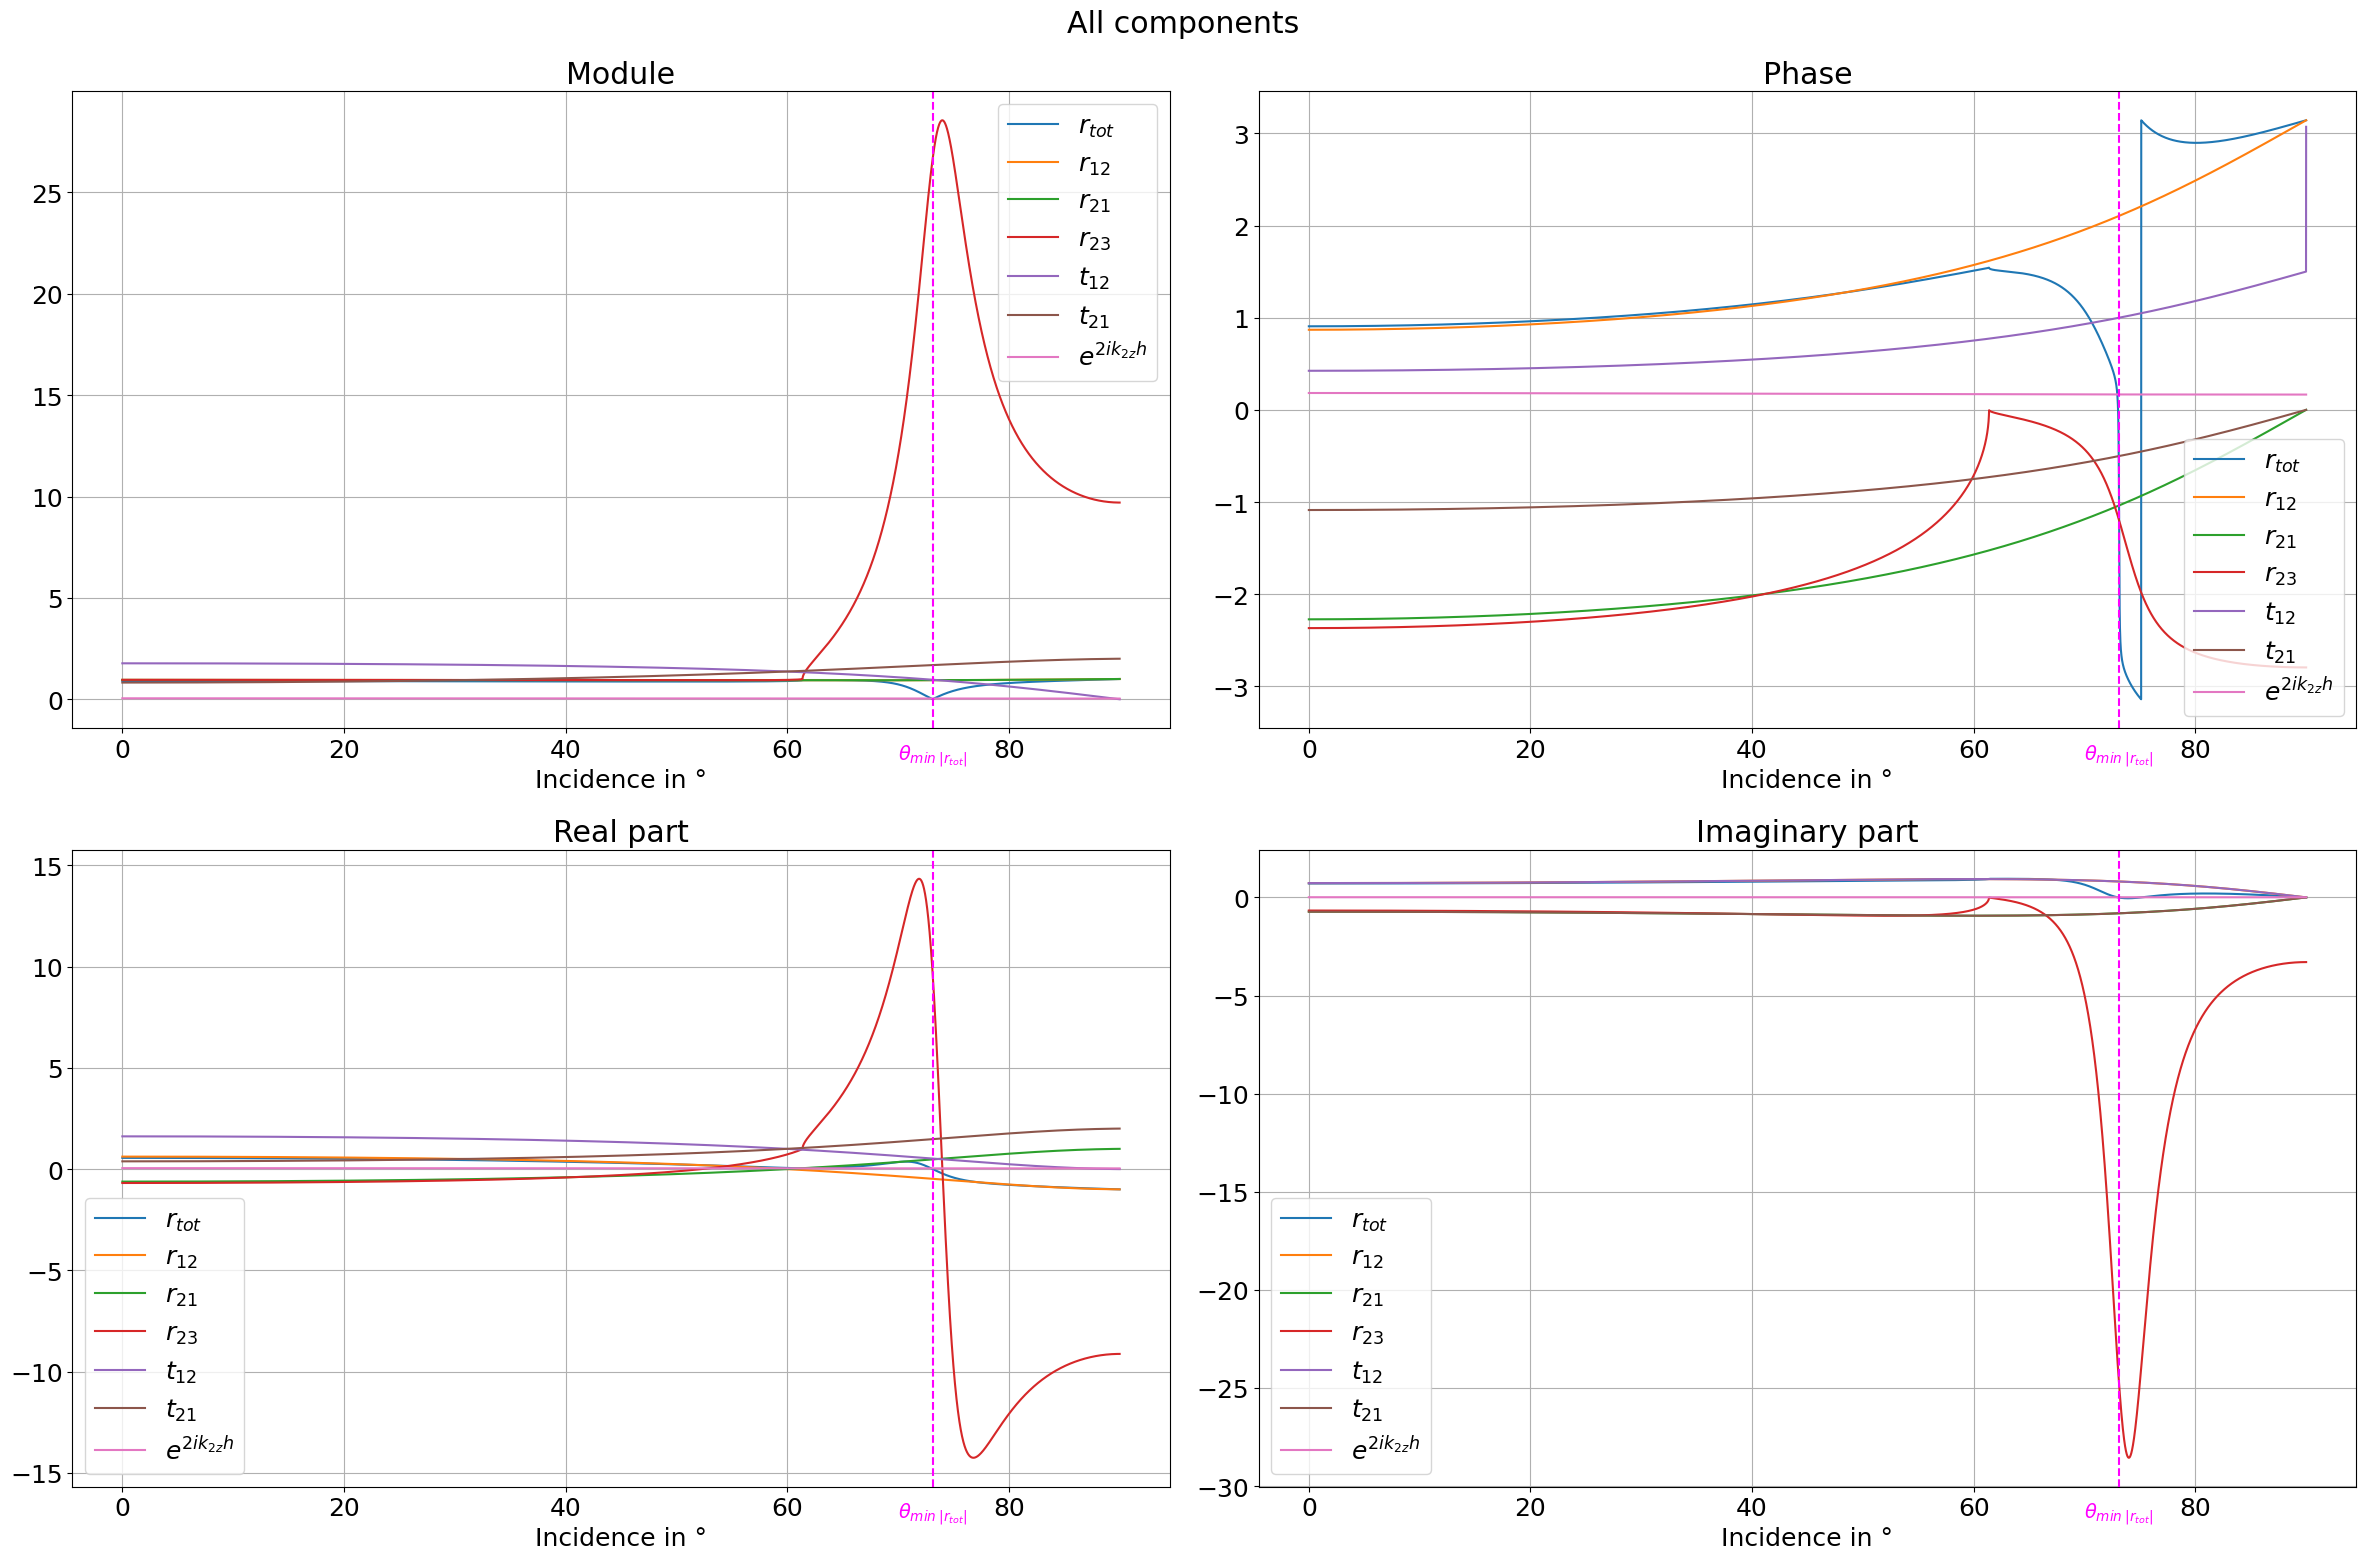

In [9]:
plt.figure(figsize=(24, 16))
plt.suptitle("All components")
ax1 = plt.subplot(2, 2, 1)
ax1.plot(incidences, np.abs(rtot), label=r"$r_{tot}$")
ax1.plot(incidences, np.abs(r12), label=r"$r_{12}$")
ax1.plot(incidences, np.abs(r21), label=r"$r_{21}$")
ax1.plot(incidences, np.abs(r23), label=r"$r_{23}$")
ax1.plot(incidences, np.abs(t12), label=r"$t_{12}$")
ax1.plot(incidences, np.abs(t21), label=r"$t_{21}$")
ax1.plot(incidences, np.abs(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax1.set_xlabel('Incidence in °')
ax1.set_title('Module')
ax1.grid()
ax1.legend()
ax2 = plt.subplot(2, 2, 2)
ax2.plot(incidences, np.angle(rtot), label=r"$r_{tot}$")
ax2.plot(incidences, np.angle(r12), label=r"$r_{12}$")
ax2.plot(incidences, np.angle(r21), label=r"$r_{21}$")
ax2.plot(incidences, np.angle(r23), label=r"$r_{23}$")
ax2.plot(incidences, np.angle(t12), label=r"$t_{12}$")
ax2.plot(incidences, np.angle(t21), label=r"$t_{21}$")
ax2.plot(incidences, np.angle(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax2.set_xlabel('Incidence in °')
ax2.set_title('Phase')
ax2.grid()
ax2.legend()
ax3 = plt.subplot(2, 2, 3)
ax3.plot(incidences, np.real(rtot), label=r"$r_{tot}$")
ax3.plot(incidences, np.real(r12), label=r"$r_{12}$")
ax3.plot(incidences, np.real(r21), label=r"$r_{21}$")
ax3.plot(incidences, np.real(r23), label=r"$r_{23}$")
ax3.plot(incidences, np.real(t12), label=r"$t_{12}$")
ax3.plot(incidences, np.real(t21), label=r"$t_{21}$")
ax3.plot(incidences, np.real(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax3.set_xlabel('Incidence in °')
ax3.set_title('Real part')
ax3.grid()
ax3.legend()
ax4 = plt.subplot(2, 2, 4)
ax4.plot(incidences, np.imag(rtot), label=r"$r_{tot}$")
ax4.plot(incidences, np.imag(r12), label=r"$r_{12}$")
ax4.plot(incidences, np.imag(r21), label=r"$r_{21}$")
ax4.plot(incidences, np.imag(r23), label=r"$r_{23}$")
ax4.plot(incidences, np.imag(t12), label=r"$t_{12}$")
ax4.plot(incidences, np.imag(t21), label=r"$t_{21}$")
ax4.plot(incidences, np.imag(np.exp(-2*kappa2z*h_Au)), label=r"$e^{2ik_{2z}h}$")
ax4.set_xlabel('Incidence in °')
ax4.set_title('Imaginary part')
ax4.grid()
ax4.legend()

# add a vertical line corresponding to the location of the r_tot module min value
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(min_rtot_loc, ls="--", color="magenta")
    ax.annotate(r'$\theta_{min\:|r_{tot}|}$',xy=(min_rtot_loc, ax.get_ylim()[0]),xytext=(0, -10),textcoords='offset points',ha='center',va='top',fontsize=14,color="magenta",transform=ax.get_xaxis_transform())

plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/r_study/r_tot_all_individual_terms.{file_ext}", bbox_inches="tight")